In [40]:
import re
import pandas as pd

from scipy.optimize import linear_sum_assignment

from analysis_shared_functions import all_samples_matrix_viz, bulk_vs_singlecell_matrix_viz

In [37]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
tool = "Vireo"
dataset = "low_grade_glioma"
pseudobulk = True
ncells = 100000
rd = 1

# Data munging

## Similarity matrix

In [23]:
if pseudobulk:
    vireo_matrix = pd.read_csv(
        DATA_PATH + 
        f"2a_vireo/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/similarity_matrix.csv", 
        index_col=0
    )
else:
    vireo_matrix = pd.read_csv(
        DATA_PATH + 
        f"2a_vireo/{dataset}/real_data/ncells_{ncells}/read_depth_{rd}/similarity_matrix.csv", 
        index_col=0
    )

In [24]:
if dataset == "hgsoc":
    regex_exp = r"[a-zA-Z0-9]{32}_"
elif dataset == "low_grade_glioma":
    regex_exp = r"^GSM[0-9]{7}_"

vireo_matrix.columns = [
    re.sub(regex_exp, "", col.replace(".bam", "").replace("ds.", "")) 
    for col in vireo_matrix.columns
]
vireo_matrix.index = pd.Index(
    [
        re.sub(regex_exp, "", idx.replace(".bam", "").replace("ds.", "")) 
        for idx in vireo_matrix.index
    ]
)

In [25]:
# Order rows and columns
ordered_columns = sorted(vireo_matrix.columns)
ordered_index = sorted(vireo_matrix.index)
vireo_matrix = vireo_matrix.loc[ordered_index, ordered_columns]

In [26]:
vireo_matrix.head()

,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_3,pseudobulk_GSM7326883_ncells_100000_1,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_3,pseudobulk_GSM7326884_ncells_100000_1,...,pseudobulk_GSM7326901_ncells_100000_3,pseudobulk_GSM7326902_ncells_100000_1,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_3,pseudobulk_GSM7326903_ncells_100000_1,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_3,pseudobulk_GSM7326905_ncells_100000_1,pseudobulk_GSM7326905_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_3
pseudobulk_GSM7326880_ncells_100000_1,0.000000,0.000000,0.000000,0.012009,0.012009,0.012009,0.023095,0.020031,0.020432,0.008699,...,0.010221,0.010859,0.010542,0.010669,0.009621,0.009629,0.009668,0.042368,0.039110,0.037996
pseudobulk_GSM7326880_ncells_100000_2,0.000000,0.000000,0.000000,0.012009,0.012009,0.012009,0.023095,0.020031,0.020432,0.008699,...,0.010221,0.010859,0.010542,0.010669,0.009621,0.009629,0.009668,0.042368,0.039110,0.037996
pseudobulk_GSM7326880_ncells_100000_3,0.000000,0.000000,0.000000,0.012009,0.012009,0.012009,0.023095,0.020031,0.020432,0.008699,...,0.010221,0.010859,0.010542,0.010669,0.009621,0.009629,0.009668,0.042368,0.039110,0.037996
pseudobulk_GSM7326881_ncells_100000_1,0.012009,0.012009,0.012009,0.000000,0.000000,0.000000,0.025429,0.022311,0.022724,0.010714,...,0.012467,0.013172,0.012845,0.012967,0.011893,0.011870,0.011948,0.044654,0.041391,0.040288
pseudobulk_GSM7326881_ncells_100000_2,0.012009,0.012009,0.012009,0.000000,0.000000,0.000000,0.025429,0.022311,0.022724,0.010714,...,0.012467,0.013172,0.012845,0.012967,0.011893,0.011870,0.011948,0.044654,0.041391,0.040288


In [27]:
vireo_matrix.shape

(66, 66)

## Sample matches

In [28]:
if pseudobulk:
    vireo_matches = pd.read_csv(
        DATA_PATH + 
        f"2a_vireo/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/matched_samples.csv", 
        index_col=0
    ).reset_index()
else:
    vireo_matches = pd.read_csv(
        DATA_PATH + 
        f"2a_vireo/{dataset}/real_data/ncells_{ncells}/read_depth_{rd}/matched_samples.csv", 
        index_col=0
    ).reset_index()

In [29]:
for col in vireo_matches.columns:
    vireo_matches[col] = [
        re.sub(regex_exp, "", sample.replace(".bam", "").replace("ds.", "")) 
        for sample in vireo_matches[col]
    ]

vireo_matches = vireo_matches.sort_values(by=["sample_id_0"]).reset_index(drop=True)

In [31]:
vireo_matches.head()

,sample_id_0,sample_id_1
0,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_1
1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_2
2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326880_ncells_100000_3
3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_1
4,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_2


# Real data viz & analysis

Bulk vs single-cell (or single-nucleus)

In [ ]:
bulk_vs_singlecell_matrix_viz(
    vireo_matrix, 
    pseudobulk=pseudobulk, 
    tool=tool, 
    dataset=dataset, 
    ncells=ncells, 
    rd=rd, 
    save_fig=False
)

## Comparison with expected matches

# Pseudobulk viz & analysis

Comparing sets of pseudobulks derived from the same samples

Accuracy / F1 / recall / ...

In [32]:
# How many correct matches? 
# Sanity check since each sample should match itself
correct_matches = vireo_matches[vireo_matches["sample_id_0"] == vireo_matches["sample_id_1"]]
print(f"Number of correct matches: {correct_matches.shape[0]} out of {vireo_matches.shape[0]}")

Number of correct matches: 66 out of 66


In [50]:
# Filter Vireo matrix to only samples ending in _1 in rows and samples ending in _2 in columns (or _2 vs _3 or _1 vs _3)
pseudobulk_1 = "_1"
pseudobulk_1_regex = r"_1$"
pseudobulk_2 = "_2"
pseudobulk_2_regex = r"_2$"
vireo_matrix_filtered = vireo_matrix.loc[
    [idx for idx in vireo_matrix.index if idx.endswith(pseudobulk_1)],
    [col for col in vireo_matrix.columns if col.endswith(pseudobulk_2)]
]

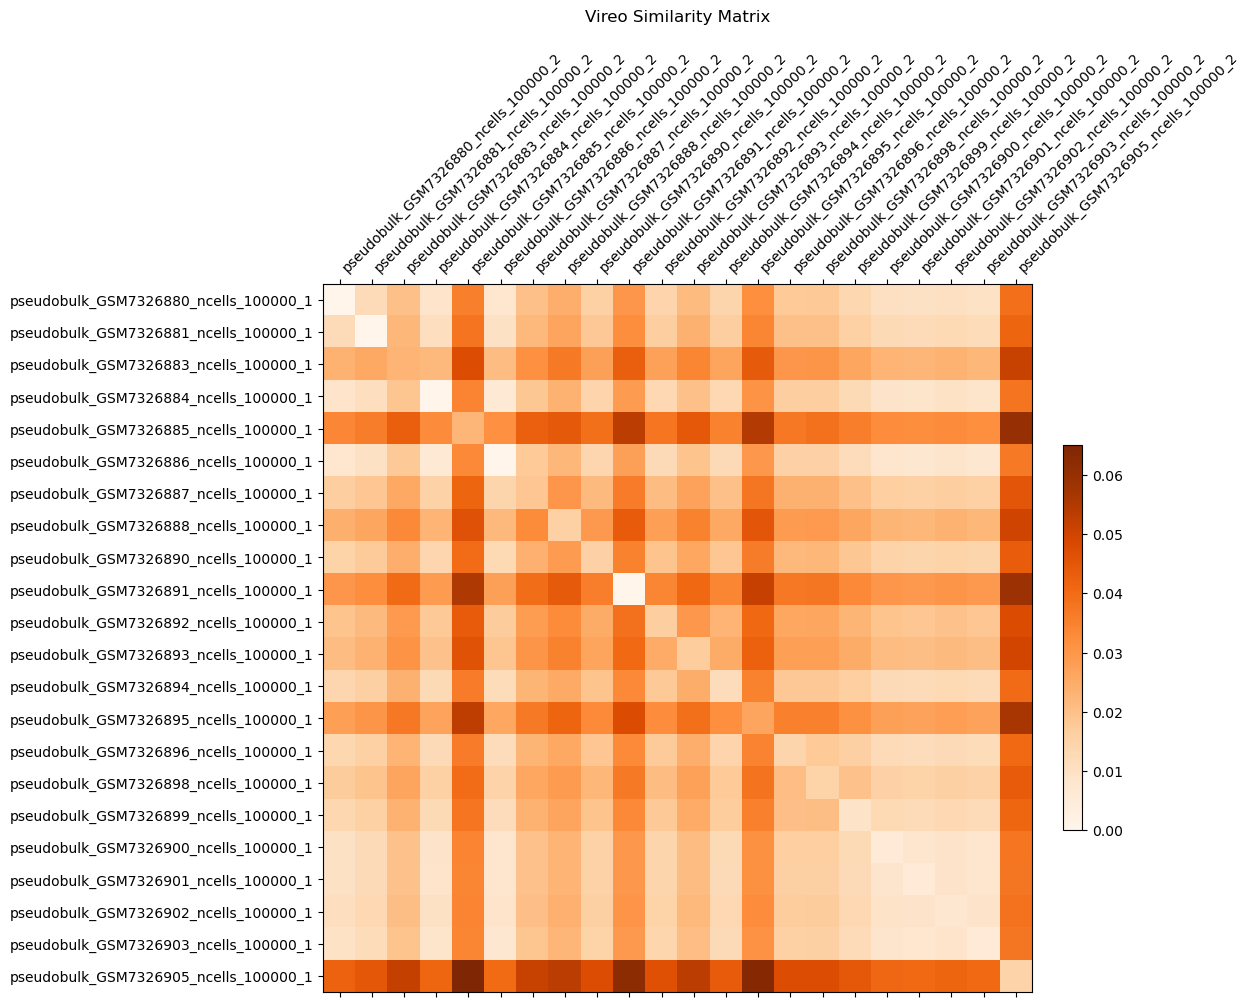

In [51]:
all_samples_matrix_viz(
    vireo_matrix_filtered, 
    pseudobulk=pseudobulk, 
    tool=tool, 
    dataset=dataset, 
    ncells=ncells, 
    rd=rd, 
    save_fig=False
)

In [52]:
# Minimize diagonal of vireo_matrix_filtered by moving rows and columns around
idx0, idx1 = linear_sum_assignment(vireo_matrix_filtered.values)
vireo_matrix_reordered = pd.DataFrame(
    vireo_matrix_filtered.iloc[idx0, idx1], 
    index=vireo_matrix_filtered.index[idx0], 
    columns=vireo_matrix_filtered.columns[idx1]
)

In [ ]:
# Rename samples by removing trailing pseudobulk number
vireo_matrix_reordered.index = [
    re.sub(pseudobulk_1_regex, "", idx) 
    for idx in vireo_matrix_reordered.index
]
vireo_matrix_reordered.columns = [
    re.sub(pseudobulk_2_regex, "", col) 
    for col in vireo_matrix_reordered.columns
]

In [55]:
# Comparing two sets of pseudobulks derived from the same samples
vireo_matches_reordered = pd.DataFrame({
    "sample_id_0": vireo_matrix_reordered.index,
    "sample_id_1": vireo_matrix_reordered.columns
})
# How many correct matches?
correct_matches = vireo_matches_reordered[vireo_matches_reordered["sample_id_0"] == vireo_matches_reordered["sample_id_1"]]
print(f"Number of correct matches: {correct_matches.shape[0]} out of {vireo_matches_reordered.shape[0]}")

Number of correct matches: 22 out of 22


In [56]:
# List incorrect matches if there are any
vireo_matches_reordered[vireo_matches_reordered["sample_id_0"] != vireo_matches_reordered["sample_id_1"]]

,sample_id_0,sample_id_1


## Detailed accuracy metrics

In [58]:
tp = 22   # True positive = correctly predicted matches
tn = 462  # True negative = correctly predicted non-matches
fp = 0    # False positive = wrongly predicted matches
fn = 0    # False negative = wrongly predicted non-matches

In [69]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
balanced_accuracy = (tpr + tnr) / 2
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy = {accuracy:.2f}")
print(f"Balanced accuracy = {balanced_accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall = {recall:.2f}")
print(f"F1 = {f1:.2f}")

Accuracy = 1.00
Balanced accuracy = 1.00
Precision = 1.00
Recall = 1.00
F1 = 1.00
